In [ ]:
!pip install shap

# GENERATE SHAP VALUES

Calculating SHAP values... (this may take 1-2 minutes)


  0%|          | 0/10 [00:00<?, ?it/s]

Original SHAP values shape: (10, 80, 1)


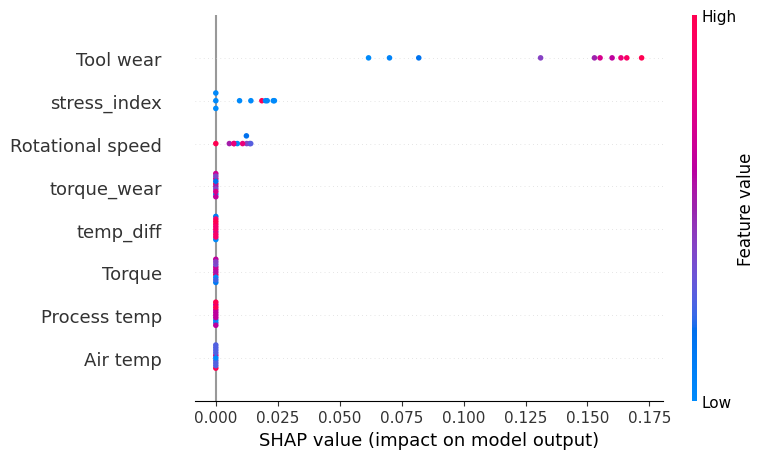

In [5]:
import numpy as np
import tensorflow as tf
import shap
import matplotlib.pyplot as plt

# 1. Load the Model and Data
model = tf.keras.models.load_model('best_lstm_attention_model_v2.keras')
X_test = np.load('X_test.npy')

feature_names = [
    'Air temp', 'Process temp', 'Rotational speed',
    'Torque', 'Tool wear', 'temp_diff', 'stress_index', 'torque_wear'
]

# 2. Select Subset and Setup Dimensions
num_samples = 10
time_steps = 10
num_features = 8

# Create background and test subset
background_data = X_test[np.random.choice(X_test.shape[0], 50, replace=False)]
test_subset = X_test[:num_samples]

# Flatten 3D to 2D for SHAP requirement (Instance must have 1 or 2 dimensions)
background_data_2d = background_data.reshape(background_data.shape[0], -1)
test_subset_2d = test_subset.reshape(num_samples, -1)

# 3. Create a Wrapper Function
def model_predict_wrapper(x_2d):
    # This turns the 2D data back to 3D just for the LSTM to process
    x_3d = x_2d.reshape(x_2d.shape[0], time_steps, num_features)
    return model.predict(x_3d, verbose=0)

# 4. Initialize and Run Explainer
explainer = shap.KernelExplainer(model_predict_wrapper, background_data_2d)

print("Calculating SHAP values... (this may take 1-2 minutes)")
shap_values = explainer.shap_values(test_subset_2d)

# 5. FIXED: Aggregation and Reshaping Logic
# shap_values is typically a list for binary classifiers [class_0_vals, class_1_vals]
# We want the values for Class 1 (Failure)
if isinstance(shap_values, list):
    # Use the second array if list, otherwise use the array directly
    vals = shap_values[1] if len(shap_values) > 1 else shap_values[0]
else:
    vals = shap_values

# Ensure vals is exactly (10, 80) before reshaping to (10, 10, 8)
print(f"Original SHAP values shape: {vals.shape}")

# Reshape to 3D to group by feature
# Resulting shape: (10 samples, 10 time steps, 8 features)
shap_3d = vals.reshape(num_samples, time_steps, num_features)

# Sum across the 10 time steps (axis=1) to get total feature importance per sample
shap_values_aggregated = np.sum(shap_3d, axis=1)

# 6. Visualization
# test_subset[:, 0, :] provides the feature values for the first time step for the plot
shap.summary_plot(shap_values_aggregated, test_subset[:, 0, :], feature_names=feature_names)

# SHAP Summary Plots

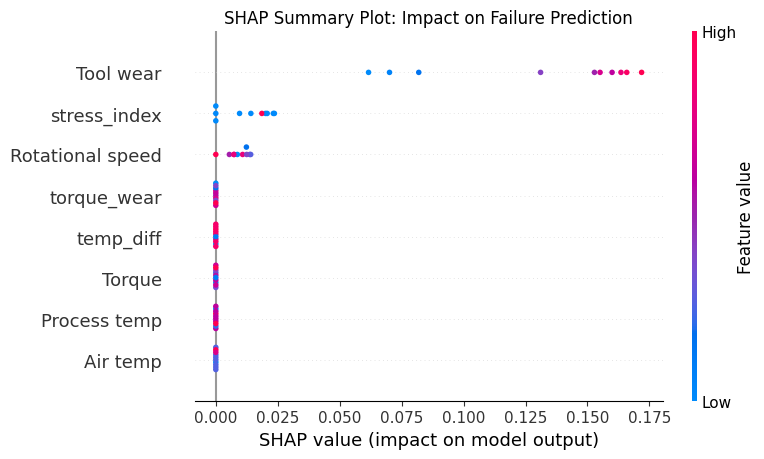

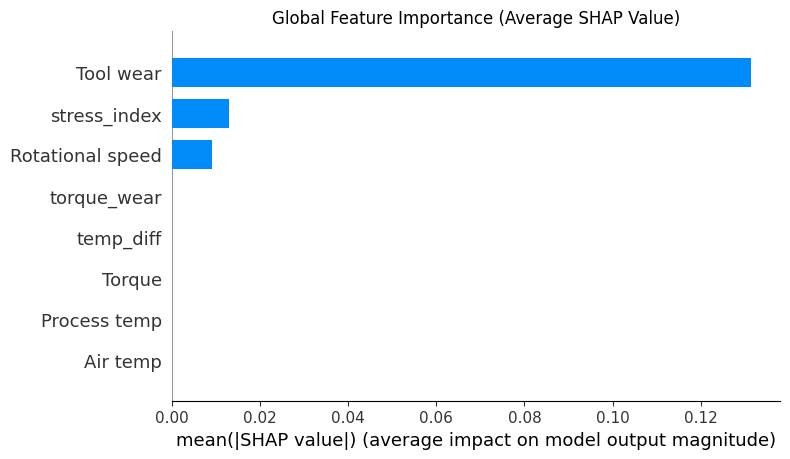

In [6]:

# 1. Standard Summary Plot (Bee-swarm)
# This shows how high/low feature values (red/blue) affect the prediction
plt.figure(figsize=(10, 6))
plt.title("SHAP Summary Plot: Impact on Failure Prediction")
shap.summary_plot(
    shap_values_aggregated,
    test_subset[:, 0, :], # We use feature values from the first time step for coloring
    feature_names=feature_names
)

# 2. Bar Plot (Global Feature Importance)
# This shows the average magnitude of each feature's contribution
plt.figure(figsize=(10, 6))
plt.title("Global Feature Importance (Average SHAP Value)")
shap.summary_plot(
    shap_values_aggregated,
    test_subset[:, 0, :],
    feature_names=feature_names,
    plot_type="bar"
)

# Local Explanation

Base Value (Average Prediction): 0.3653


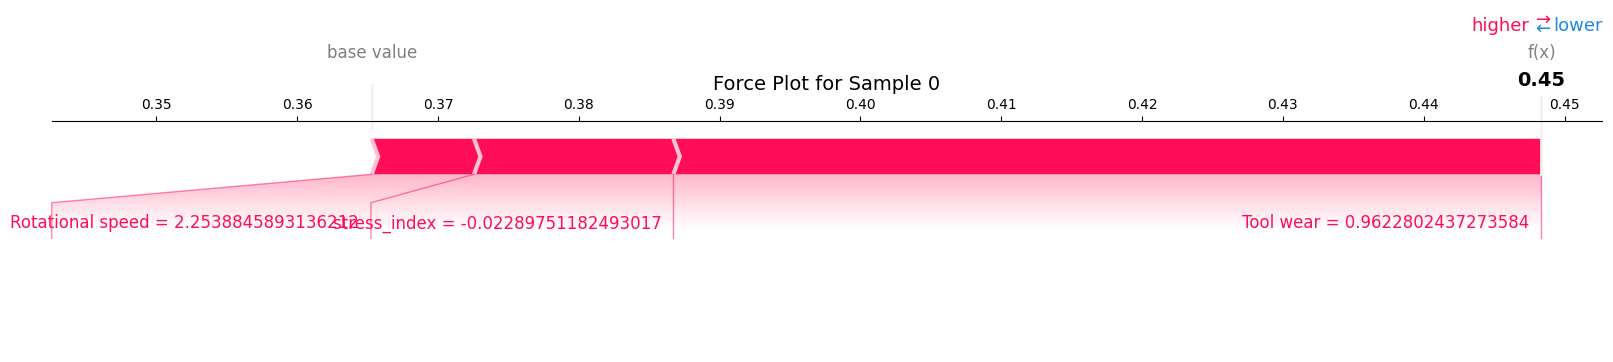

In [8]:
# 1. Initialize Javascript for SHAP (helpful for interactive notebooks)
shap.initjs()

# 2. Select the specific sample you want to explain
# Let's pick the first sample from our subset
sample_idx = 0

# 3. Handle the expected_value logic safely
# Since your model has 1 output (sigmoid), expected_value is likely an array of size 1
if isinstance(explainer.expected_value, (list, np.ndarray)):
    # If it's an array/list, try to get the value.
    # If size is 1, use index 0. Otherwise, use index 1 (for binary classes).
    if len(explainer.expected_value) > 1:
        base_value = explainer.expected_value[1]
    else:
        base_value = explainer.expected_value[0]
else:
    # If it's just a single scalar float
    base_value = explainer.expected_value

print(f"Base Value (Average Prediction): {base_value:.4f}")

# 4. Extract SHAP and Feature values for this specific sample
# We use the aggregated values (summed over 10 minutes)
sample_shap_values = shap_values_aggregated[sample_idx]

# We use feature values from the most recent time step (-1) for display labels
sample_feature_values = test_subset[sample_idx, -1, :]

# 5. Generate the Force Plot
# We use matplotlib=True to ensure it renders as a static image in Colab/Jupyter
shap.force_plot(
    base_value,
    sample_shap_values,
    sample_feature_values,
    feature_names=feature_names,
    matplotlib=True,
    show=False # Allows further customization with plt if needed
)

plt.title(f"Force Plot for Sample {sample_idx}", fontsize=14)
plt.show()

47/47 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step


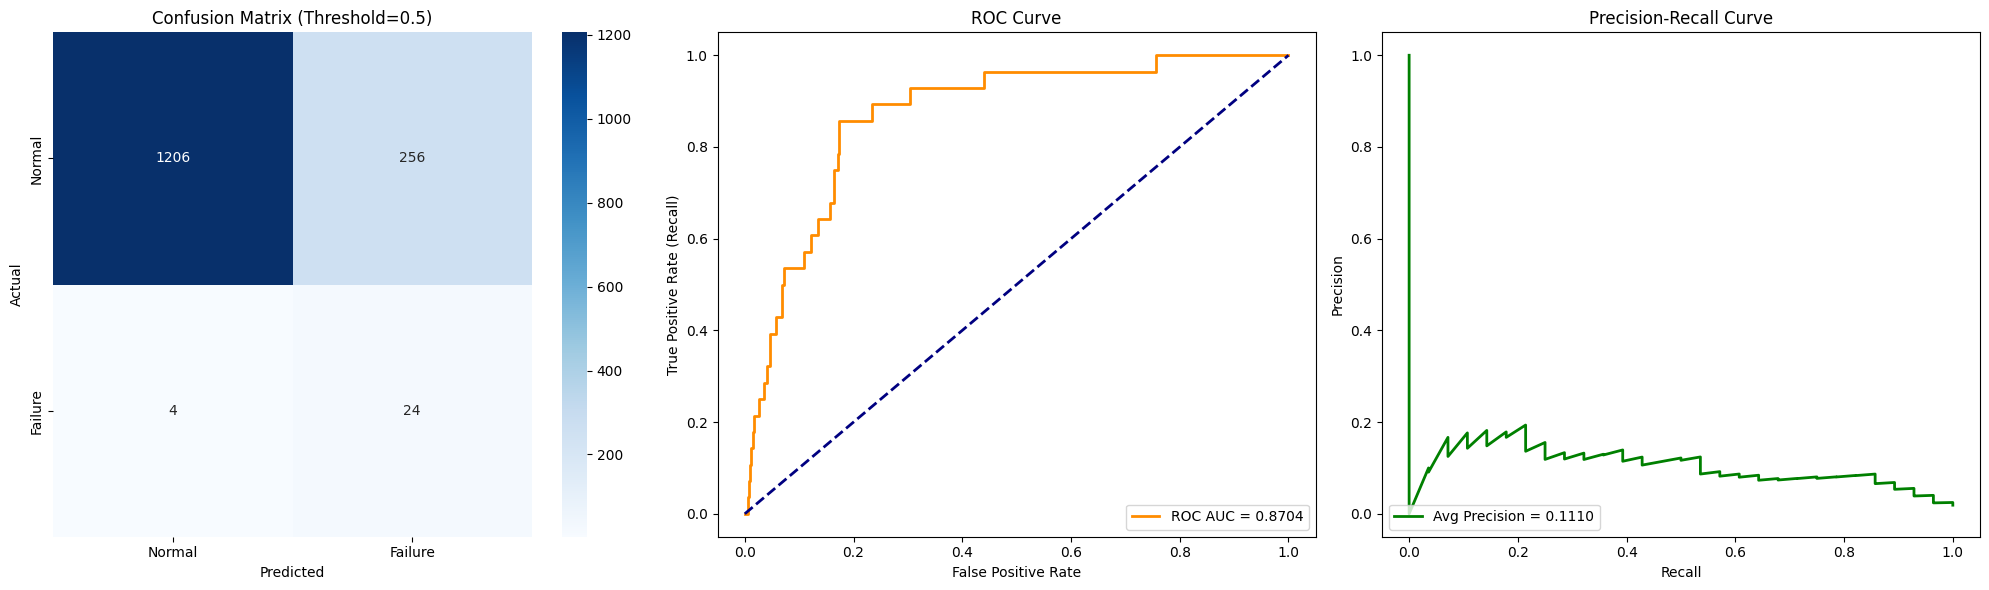

In [11]:
import seaborn as sns
from sklearn.metrics import (
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)

def plot_model_evaluation(y_true, y_probs, threshold=0.5):
    # Convert probabilities to binary predictions based on threshold
    y_pred = (y_probs >= threshold).astype(int)

    # Create the figure with 3 subplots
    fig, axes = plt.subplots(1, 3, figsize=(20, 6))

    # --- 1. Confusion Matrix ---
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
                xticklabels=['Normal', 'Failure'],
                yticklabels=['Normal', 'Failure'])
    axes[0].set_title(f'Confusion Matrix (Threshold={threshold})')
    axes[0].set_xlabel('Predicted')
    axes[0].set_ylabel('Actual')

    # --- 2. ROC Curve ---
    fpr, tpr, _ = roc_curve(y_true, y_probs)
    roc_auc = auc(fpr, tpr)
    axes[1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC AUC = {roc_auc:.4f}')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
    axes[1].set_title('ROC Curve')
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate (Recall)')
    axes[1].legend(loc="lower right")

    # --- 3. Precision-Recall Curve ---
    precision, recall, _ = precision_recall_curve(y_true, y_probs)
    avg_precision = average_precision_score(y_true, y_probs)
    axes[2].plot(recall, precision, color='green', lw=2, label=f'Avg Precision = {avg_precision:.4f}')
    axes[2].set_title('Precision-Recall Curve')
    axes[2].set_xlabel('Recall')
    axes[2].set_ylabel('Precision')
    axes[2].legend(loc="lower left")

    plt.tight_layout()
    plt.show()

# --- RUN EVALUATION ---
# Assuming you already have y_test and your model's predictions:
# y_probs = best_model.predict(X_test)
y_test = np.load('/content/y_test.npy')
y_probs = model.predict(X_test)
plot_model_evaluation(y_test, y_probs)